In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from numpy.linalg import svd
from sklearn import datasets
from scipy.linalg import norm
from sklearn.decomposition import PCA

The following code returns the dataset of 40 images.

In [2]:
data = datasets.fetch_olivetti_faces()
images = data.images

In [3]:
#get shapes
print(images.shape)

(400, 64, 64)


(a) Given an $m \times n$ image $M$ and its rank-$k$ approximation $A$, we can measure the reconstruction error using mean $\ell_1$ error: $$ \text{error}_{\ell_1}(M, A) = \frac{1}{mn}\| M - A \|_1 = \frac{1}{mn}\sum_{i=1}^{m}\sum_{j=1}^{n}| M_{i,j} - A_{i,j} |. $$ For $k = 1, \dots, 30$, take the average rank-$k$ reconstruction error over all images in the dataset, and plot a curve of average reconstruction error as a function of $k$.

In [4]:
# Returns the best rank-k approximation to M
def svd_reconstruct(M, k):
    m, n =  M.shape[0], M.shape[1]
    U, s, VT = svd(M, full_matrices = False)
    Sigma = np.zeros((M.shape[0], M.shape[1]))
    Sigma[:min(M.shape[0], M.shape[1]), :min(M.shape[0], M.shape[1])] = np.diag(s)
    # Reconstruction of the matrix using the first k singular values
    A = U[:, :k] @ Sigma[:k, :k] @ VT[:k, :]
    # Calculate error
    mat_error = M - A
    reconstuction_error = (norm(mat_error, 1))/(m*n)
    return k,reconstuction_error

In [5]:
#test
#svd_reconstruct(images[0],1)

In [6]:
#run for k 1:30
error = []
for k in range(1,31):
    for i in range(0,images.shape[0]-1):
        k,reconstruct_error= svd_reconstruct(images[i],k)
        k_error =[k,reconstruct_error]
        error.append(k_error)

Text(0, 0.5, 'Mean of Reconstruction_Error')

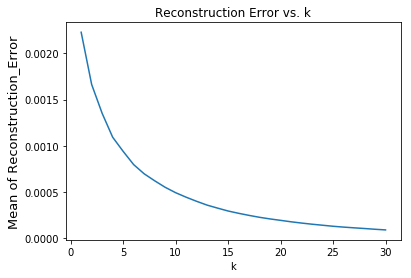

In [7]:
#plot k vs. reconstruction error
df = pd.DataFrame(error)
df.columns = ["k","error"]
mean_recon_error = df.groupby('k').mean()

#plot
plt.title('Reconstruction Error vs. k')
plt.plot(mean_recon_error['error'])

plt.xlabel("k")
plt.ylabel("Mean of Reconstruction_Error", fontsize=13)

Comments: The mean reconstruction error gets close to zero as K gets larger, almost reaching to zero when K is 30. 

(b) Pick any image in the dataset, and display the following side-by-side as images: the original, and the best rank-$k$ approximations for $k = 10, 20, 30, 40$. You will find the `imshow` method in matplotlib useful for this; pass in `cmap='gray'` to render in grayscale. Feel free to play around further.

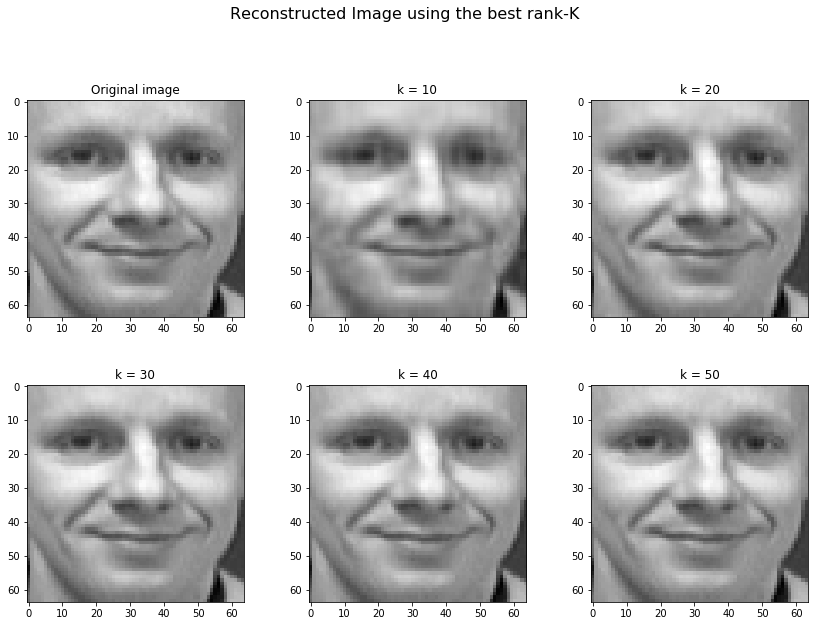

In [8]:
# choose a random image
M=images[200]

U, s, VT = svd(M, full_matrices=False)
Sigma = np.zeros((M.shape[0], M.shape[1]))
Sigma[:min(M.shape[0], M.shape[1]), :min(M.shape[0], M.shape[1])] = np.diag(s)

fig, axes = plt.subplots(2, 3, figsize=(14, 10))
fig.suptitle("Reconstructed Image using the best rank-K", fontsize=16)
plt.subplots_adjust(wspace=0.3, hspace=0.1)

axes[0, 0].imshow(M, cmap='gray')
axes[0, 0].set_title("Original image")

k_list = [10, 20, 30, 40,50]  #Added k= 50

for i in range(1, 6):
    k = k_list[i-1]
    # Reconstruction of the matrix using the first k singular values
    A = U[:, :k] @ Sigma[:k, :k] @ VT[:k, :]
    axes[i // 3, i % 3].imshow(A.reshape((64,64)), cmap='gray')
    axes[i // 3, i % 3].set_title("k = {}".format(k))

plt.show()

Comments: The reconstructed image with k=10 is a bit blurry. From k=20 to k=50, these reconstructed images look similar. 
It is consistent with the error graph above, the marginal gain as k gets larger is smaller. 

# Problem 2

In this problem we visualize the Wisconsin breast cancer dataset in two dimensions using PCA. First, rescale the data so that every feature has mean 0 and standard deviation 1 across the various points in the dataset. You may find `sklearn.preprocessing.StandardScaler` useful for this. Next, compute the top two principal components of the dataset using PCA, and for every data point, compute its coordinates (i.e. projections) along these two principal components. You should do this in two ways:
1. By using SVD directly. Do not use any PCA built-ins.
2. By using `sklearn.decomposition.PCA`.

The two approaches should give exactly the same result, and this also acts as a check. (But note that the signs of the singular vectors may be flipped in the two approaches since singular vectors are only determined uniquely up to sign. If this happens, flip signs to make everything identical again.)

Your final goal is to make a scatterplot of the dataset in 2 dimensions, where the x-axis is the first principal component and the y-axis is the second. Color the points by their diagnosis (malignant or benign). Do this for both approaches. Your plots should be identical. Does the data look roughly separable already in 2 dimensions?

In [9]:
cancer = datasets.load_breast_cancer()

In [10]:
# change to panda dataframe
df = pd.DataFrame(cancer.data, columns=cancer.feature_names)

In [11]:
# Rescale the data: mean 0 and std 1
from sklearn.preprocessing import StandardScaler

# transform data
X = StandardScaler().fit_transform(df)

Sigma:  [[86.93235745  0.        ]
 [ 0.         56.90677266]
 [ 0.          0.        ]
 ...
 [ 0.          0.        ]
 [ 0.          0.        ]
 [ 0.          0.        ]]
Projected:  [[ 9.19283683  1.94858307]
 [ 2.3878018  -3.76817174]
 [ 5.73389628 -1.0751738 ]
 ...
 [ 1.25617928 -1.90229671]
 [10.37479406  1.67201011]
 [-5.4752433  -0.67063679]]


Text(0, 0.5, 'Prin Comp 2')

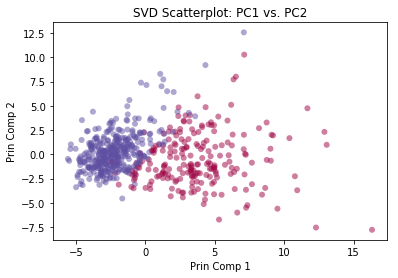

In [12]:
# Approach 1: Use SVD Directly 

U, s, VT = svd(X, full_matrices=True)

# create m x n Sigma matrix
Sigma = np.zeros((X.shape[0], X.shape[1]))

# populate Sigma with n x n diagonal matrix
Sigma[:X.shape[1], :X.shape[1]] = np.diag(s)

# choose two prin components
n = 2
Sigma = Sigma[:, :n]  
print("Sigma: " ,Sigma)
VT = VT[:n, :]

# transforms of the original matrix.
U = -U  #flip signs
svd_projected = U.dot(Sigma)
print("Projected: ", svd_projected) 

plt.title('SVD Scatterplot: PC1 vs. PC2')
plt.scatter(svd_projected[:, 0], svd_projected[:, 1],
            c=cancer.target, edgecolor='none', alpha=0.5,
            cmap=plt.cm.get_cmap('Spectral', 2))
plt.xlabel('Prin Comp 1')
plt.ylabel('Prin Comp 2')

original shape:    (569, 30)
transformed shape: (569, 2)
singular values:    [86.93235745 56.90677266]
Projected:  [[ 9.19283683  1.94858307]
 [ 2.3878018  -3.76817174]
 [ 5.73389628 -1.0751738 ]
 ...
 [ 1.25617928 -1.90229671]
 [10.37479406  1.67201011]
 [-5.4752433  -0.67063679]]


Text(0, 0.5, 'Prin Comp 2')

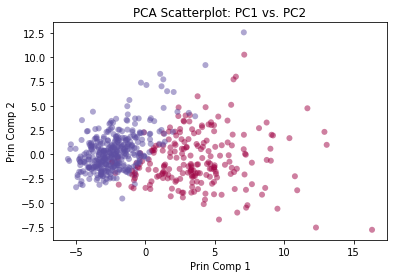

In [13]:
#Approach 2: PCA to compute two principal components

pca = PCA(n_components=2)
pca_projected = pca.fit_transform(X)

print("original shape:   ", X.shape)
print("transformed shape:", pca_projected.shape)
print("singular values:   ", pca.singular_values_)
print("Projected: ", pca_projected)

plt.title('PCA Scatterplot: PC1 vs. PC2')
plt.scatter(pca_projected[:, 0], pca_projected[:, 1],
            c=cancer.target, edgecolor='none', alpha=0.5,
            cmap=plt.cm.get_cmap('Spectral', 2))
plt.xlabel('Prin Comp 1')
plt.ylabel('Prin Comp 2')

Comments: These two implementation methods yield the same results. It can be seen that the data is separated pretty nicely with these two principal components. 